In [8]:
import torch
from collections import OrderedDict  

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt
import scipy.io 
from scipy.interpolate import griddata 

import random

import skopt 
from distutils.version import LooseVersion 

from mpl_toolkits.axes_grid1 import make_axes_locatable 
import matplotlib.gridspec as gridspec 
import time 


from tqdm import tqdm 

import os
import pickle

import timeit 
import seaborn as sns 
import pandas as pd

import sys 
sys.path.insert(0, '../..') 
from util import *

In [9]:
torch.cuda.set_device(0) 

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [10]:
import gc
import math
import torch
import torch.nn as nn
from einops import rearrange, repeat
from util import get_clones
import torch.nn.functional as F

class WaveAct(nn.Module):
    def __init__(self):
        super(WaveAct, self).__init__() 
        self.w1 = nn.Parameter(torch.ones(1), requires_grad=True)
        self.w2 = nn.Parameter(torch.ones(1), requires_grad=True)

    def forward(self, x):
        return self.w1 * torch.sin(x)+ self.w2 * torch.cos(x)

class PScan(torch.autograd.Function):
    """

    An implementation of the parallel scan operation in PyTorch (Blelloch version).
    This code is based on Francois Fleuret’s pscan (all credits to him). However, the keys differences are :
    -it has been written in an iterative way (rather than recursive)
    -the backward pass has been rewritten

    Please see docs/pscan.ipynb for a detailed explanation of what happens here.

    Example:
    pscan = PScan.apply

    x = torch.randn(2, 3, 4, 5, requires_grad=True)
    y = torch.randn(2, 3, 4, 5, requires_grad=True)

    model = pscan(x, y)
    model.sum().backward()
    print(x.grad)
    print(y.grad)

    """

    @staticmethod
    def pscan(A, X):
        # A : (B, D, L, N)
        # X : (B, D, L, N)

        # modifies X in place by doing a parallel scan.
        # more formally, X will be populated by these values :
        # H[t] = A[t] * H[t-1] + X[t] with H[0] = 0
        # which are computed in parallel (2*log2(T) sequential steps (ideally), instead of T sequential steps)

        B, D, L, _ = A.size()
        num_steps = int(math.log2(L))

        # up sweep or reduction step
        Aa = A
        Xa = X
        for k in range(num_steps):
            T = 2 * (Xa.size(2) // 2)

            Aa = Aa[:, :, :T].view(B, D, T // 2, 2, -1)
            Xa = Xa[:, :, :T].view(B, D, T // 2, 2, -1)

            abc = Aa[:, :, :, 1].mul(Xa[:, :, :, 0]).detach()
            Xa[:, :, :, 1].add_(abc)
            Aa[:, :, :, 1].mul_(Aa[:, :, :, 0])

            Aa = Aa[:, :, :, 1]
            Xa = Xa[:, :, :, 1]

        # down sweep
        for k in range(num_steps - 1, -1, -1):
            Aa = A[:, :, 2**k - 1 : L : 2**k]
            Xa = X[:, :, 2**k - 1 : L : 2**k]

            T = 2 * (Xa.size(2) // 2)

            if T < Xa.size(2):
                bcd = Aa[:, :, -1].mul(Xa[:, :, -2]).detach()
                Xa[:, :, -1].add_(bcd)
                Aa[:, :, -1].mul_(Aa[:, :, -2])

            Aa = Aa[:, :, :T].view(B, D, T // 2, 2, -1)
            Xa = Xa[:, :, :T].view(B, D, T // 2, 2, -1)

            cdf=Aa[:, :, 1:, 0].mul(Xa[:, :, :-1, 1]).detach()
            Xa[:, :, 1:, 0].add_(cdf)
            Aa[:, :, 1:, 0].mul_(Aa[:, :, :-1, 1])


    @staticmethod
    def forward(ctx, A_in, X_in):
        """
        Applies the parallel scan operation, as defined above. Returns a new tensor.

        Args:
            A_in : (B, L, D, N)
            X_in : (B, L, D, N)

        Returns:
            H : (B, L, D, N)
        """

        # clone tensor (in-place ops)
        A = A_in.clone()  # (B, L, D, N)
        X = X_in.clone()  # (B, L, D, N)

        # prepare tensors
        A = A.transpose(2, 1)  # (B, D, L, N)
        X = X.transpose(2, 1)  # (B, D, L, N)

        # parallel scan
        PScan.pscan(A, X)

        ctx.save_for_backward(A_in, X)

        
        return X.transpose(2, 1)

    @staticmethod
    def backward(ctx, grad_output_in):
        """
        Flows the gradient from the output to the input. Returns two new tensors.

        Args:
            ctx : A_in : (B, L, D, N), X : (B, D, L, N)
            grad_output_in : (B, L, D, N)

        Returns:
            gradA : (B, L, D, N), gradX : (B, L, D, N)
        """

        A_in, X = ctx.saved_tensors

        # clone tensors
        A = A_in.clone()
        # grad_output_in will be cloned with flip()

        # prepare tensors
        A = A.transpose(2, 1)  # (B, D, L, N)
        A = torch.cat((A[:, :, :1], A[:, :, 1:].flip(2)), dim=2)
        grad_output_b = grad_output_in.transpose(2, 1)

        # reverse parallel scan
        grad_output_b = grad_output_b.flip(2)
        PScan.pscan(A, grad_output_b)
        grad_output_b = grad_output_b.flip(2)

        Q = torch.zeros_like(X)
        Q[:, :, 1:].add_(X[:, :, :-1] * grad_output_b[:, :, 1:])

        
        

        return Q.transpose(2, 1), grad_output_b.transpose(2, 1)


pscan = PScan.apply


class SSM(nn.Module):
    def __init__(self, in_features, dt_rank, dim_inner, d_state):
        super().__init__()
        self.dt_rank = dt_rank
        self.dim_inner = dim_inner
        self.d_state = d_state

        self.deltaBC_layer = nn.Linear(in_features, dt_rank + 2 * d_state, bias=True)
        self.dt_proj_layer = nn.Linear(dt_rank, dim_inner, bias=True)

        self.A_log = nn.Parameter(torch.log(torch.arange(1, d_state + 1, dtype=torch.float32).repeat(dim_inner, 1)))
        self.D = nn.Parameter(torch.ones(dim_inner))

    def forward(self, x, pscan=True):
        A = -torch.exp(self.A_log.float())
        D = self.D.float()

        deltaBC = self.deltaBC_layer(x)
        delta, B, C = torch.split(deltaBC, [self.dt_rank, self.d_state, self.d_state], dim=-1)
        delta = F.softplus(self.dt_proj_layer(delta))

        #if pscan:
        #    y = self.selective_scan(x, delta, A, B, C, D)
        #else:
        y = self.selective_scan_seq(x, delta, A, B, C, D)

        return y

    def selective_scan(self, x, delta, A, B, C, D):
        _, L, _ = x.shape

        deltaA = torch.exp(delta.unsqueeze(-1) * A)
        deltaB = delta.unsqueeze(-1) * B.unsqueeze(2)
        BX = deltaB * x.unsqueeze(-1)

        hs = pscan(deltaA, BX)

        y = (hs @ C.unsqueeze(-1)).squeeze() + D * x

        return y

    def selective_scan_seq(self, x, delta, A, B, C, D):
        _, L, _ = x.shape

        deltaA = torch.exp(delta.unsqueeze(-1) * A)
        deltaB = delta.unsqueeze(-1) * B.unsqueeze(2)
        BX = deltaB * x.unsqueeze(-1)

        h = torch.zeros(x.size(0), self.dim_inner, self.d_state, device=deltaA.device)
        hs = []

        for t in range(L):
            h = deltaA[:, t] * h + BX[:, t]
            hs.append(h)

        hs = torch.stack(hs, dim=1)
        y = (hs @ C.unsqueeze(-1)).squeeze() + D * x

        return y

class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads, dt_rank=32, dim_inner=None, d_state=None):
        super().__init__()
        
        self.ssm = SSM(d_model, dt_rank, dim_inner, d_state)
        self.act1 = WaveAct()
        self.act2 = WaveAct()
        self.z_proj = nn.Linear(d_model, d_model)
        self.x_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.conv1d = nn.Conv1d(d_model, d_model, 1)
        self.softplus = nn.Softplus()
        #self.layernorm = nn.LayerNorm(d_model)

    def forward(self, x):
        skip = x
        #x = self.layernorm(x)
        
        z = self.z_proj(x)
        z = self.act1(z)
        x = self.x_proj(x)
        x = rearrange(x, "b s d -> b d s")
        x = self.softplus(self.conv1d(x))
        x = rearrange(x, "b d s -> b s d")
        #x = self.layernorm(x)
        x = self.act2(x)
        x = self.ssm(x)

        x = x * z
        x = self.out_proj(x)
        x = skip + x
        #x2 = self.act2(x)
        #x2 = self.layernorm(x2)
        #x = x + self.ff(x2)

        
        

        return x

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=256):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(d_model, d_ff),
            WaveAct(),
            nn.Linear(d_ff, d_ff),
            WaveAct(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.linear(x)
    

class Encoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super().__init__()
        self.N = N
        self.layers = get_clones(EncoderLayer(d_model, heads, 8, 32, 8), N)
        self.act = WaveAct()
        

    def forward(self, x):
        for i in range(self.N):
            x = self.layers[i](x)
            
        return self.act(x)
    



class DNN(nn.Module):
    def __init__(self, d_out, d_model, d_hidden, N, heads): #接受参数为：d_out代表整个模型的输出的维度（就是最后的mlp层的输出维度），d_model代表每个点的特征嵌入维度，d_hidden代表最后的output layer模块中的隐藏层的维度，N代表编码器和解码器的层数，heads代表多头注意力机制的头数
        super(DNN, self).__init__()

        self.linear_emb = nn.Linear(2, d_model) #线性层，将输入的2维数据映射到d_model维度

        self.encoder = Encoder(d_model, N, heads) #编码器层
        # self.decoder = Decoder(d_model, N, heads) #解码器层

        #输出的mlp模块，包含三个线性层，前两个使用自定义激活函数WaveAct，最终将feature从d_model维度映射到d_hidden维度，最后将d_hidden维度映射到d_out维度
        self.linear_hidden = nn.Sequential(*[
            nn.Linear(d_model, d_hidden),
            WaveAct(),
            nn.Linear(d_hidden, d_hidden),
            WaveAct(),
            nn.Linear(d_hidden, 2),
        ])
        self.linear_out = nn.Sequential(*[
            WaveAct(),
            nn.Linear(2, d_out)
        ])

    def forward(self, x): #输入的x形状一般为(点的数量, 序列长度, 2)
        src = x #形状为(点的数量，序列长度，2)
        src = self.linear_emb(src) #特征向量通过第一个线性层，映射到高维，此时src的形状为(点的数量，序列长度，d_model)，d_model代表每个点的特征

        e_outputs = self.encoder(src) #编码器处理输入特征向量，得到编码后的输出，形状为(点的数量，序列长度，d_model)
        # d_output = self.decoder(src, e_outputs) #解码器处理输入特征向量和编码后的输出，得到解码后的输出，形状为(点的数量，序列长度，d_model)
        output_hidden = self.linear_hidden(e_outputs) #解码后的输出通过输出的mlp模块，得到最终的预测结果。形状为(点的数量，序列长度，2)，d_out代表输出的维度
        output = self.linear_out(output_hidden) #形状为(点的数量，序列长度，d_out)，d_out代表输出的维度
        # pdb.set_trace()
        # raise Exception('stop')
        return output #(点的数量，序列长度，d_out)
    
    # 新增方法，获取最后一个隐藏层的输出
    def hidden_output(self, x):
        src = x #形状为(点的数量，序列长度，2)
        src = self.linear_emb(src) #特征向量通过第一个线性层，映射到高维，此时src的形状为(点的数量，序列长度，d_model)，d_model代表每个点的特征

        e_outputs = self.encoder(src) #编码器处理输入特征向量，得到编码后的输出，形状为(点的数量，序列长度，d_model)
        # d_output = self.decoder(src, e_outputs) #解码器处理输入特征向量和编码后的输出，得到解码后的输出，形状为(点的数量，序列长度，d_model)
        output_hidden = self.linear_hidden(e_outputs) #解码后的输出通过输出的mlp模块，得到最终的预测结果。形状为(点的数量，序列长度，2)，d_out代表输出的维度
        # output = self.linear_out(output_hidden) #形状为(点的数量，序列长度，d_out)，d_out代表输出的维度
        # pdb.set_trace()
        # raise Exception('stop')
        return output_hidden #(点的数量，序列长度，2)

    
   

In [11]:

class PhysicsInformedNN():
    def __init__(self, b_left, b_right, b_upper, b_lower, X_f, lb, ub): 
        self.lb = torch.tensor(lb).float().to(device) 
        self.ub = torch.tensor(ub).float().to(device)

        X_f = make_time_sequence(X_f, num_step=7, step=1e-2) 

        b_left = make_time_sequence(b_left, num_step=7, step=1e-2) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        b_right = make_time_sequence(b_right, num_step=7, step=1e-2) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        b_upper = make_time_sequence(b_upper, num_step=7, step=1e-2) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        b_lower = make_time_sequence(b_lower, num_step=7, step=1e-2) #将形状从(点的数量，2)变为(点的数量，序列长度，2)\n",
        
        # data
        #配位点数据
        self.x_f = torch.tensor(X_f[:,:, 0:1], requires_grad=True).float().to(device)
        self.t_f = torch.tensor(X_f[:,:, 1:2], requires_grad=True).float().to(device)

        self.x_left = torch.tensor(b_left[:,:, 0:1], requires_grad=True).float().to(device) #(点的数量，序列长度，1)\n",
        self.t_left = torch.tensor(b_left[:,:, 1:2], requires_grad=True).float().to(device)
        self.x_right = torch.tensor(b_right[:,:, 0:1], requires_grad=True).float().to(device) 
        self.t_right = torch.tensor(b_right[:,:, 1:2], requires_grad=True).float().to(device)
        self.x_upper = torch.tensor(b_upper[:,:, 0:1], requires_grad=True).float().to(device) 
        self.t_upper = torch.tensor(b_upper[:,:, 1:2], requires_grad=True).float().to(device)
        self.x_lower = torch.tensor(b_lower[:,:, 0:1], requires_grad=True).float().to(device)
        self.t_lower = torch.tensor(b_lower[:,:, 1:2], requires_grad=True).float().to(device)
        
        
        # deep neural networks
        self.dnn = DNN(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device) 
        self.dnn.apply(self.init_weights) 
        
 
        self.optimizer_LBFGS = torch.optim.LBFGS(self.dnn.parameters(), line_search_fn='strong_wolfe') 

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters())

        self.optimizer_SGD = torch.optim.SGD(self.dnn.parameters(), lr=0.01, momentum=0.9)

        self.iter = 0 

        self.loss_value = [] 

    def init_weights(self, m):
        if isinstance(m, nn.Linear): 
            torch.nn.init.xavier_uniform(m.weight)
            m.bias.data.fill_(0.01)

    def net_u(self, x, t):  
        u = self.dnn(torch.cat([x, t], dim=-1))  
        return u

    def net_f(self, x, t):
        """ The pytorch autograd version of calculating residual """
        u = self.net_u(x, t) 
        u_t = torch.autograd.grad(
            u, t,  
            grad_outputs=torch.ones_like(u), 
            retain_graph=True, 
            create_graph=True 
        )[0]

        
        f=u_t - 5 * u * (1-u) 
        return f #(点的数量，序列长度，1)
    
    def loss_func(self):
        self.optimizer_LBFGS.zero_grad() 
        
        pred_upper = self.net_u(self.x_upper, self.t_upper) 
        pred_lower = self.net_u(self.x_lower, self.t_lower) 
        pred_left = self.net_u(self.x_left, self.t_left) 
        f_pred = self.net_f(self.x_f, self.t_f) 

        loss_res = torch.mean(f_pred ** 2)
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2)
        loss_ic = torch.mean((pred_left[:,0] - torch.exp(- (self.x_left[:,0] - torch.pi)**2 / (2*(torch.pi/4)**2))) ** 2)

        # loss = loss_res + loss_bc + loss_ic
        #改下面的这些
        step_size = 1e-2 #改了
        num_step = 7 #改了
        seq_diff = int(1e-2/step_size) #改了，加的东西
        # loss_seq = torch.mean((f_pred[51:2601,0:num_step-seq_diff,:]-f_pred[0:2550,seq_diff:num_step,:]) ** 2) #这里主要是51、2601和2550三个数，跟训练数据X_f有关，X_f数量是51*51，2550=2601-51
        loss_seq = torch.mean((f_pred[101:10201,0:num_step-seq_diff,:]-f_pred[0:10100,seq_diff:num_step,:]) ** 2)
        loss = loss_res + loss_bc + loss_ic + 0.1 / num_step * loss_seq
        loss.backward() 

        self.iter += 1 
        self.loss_value.append(loss) 

        return loss #返回loss

      
    
    def train(self, nIter, nIterLBFGS):
        self.dnn.train()
        for epoch in tqdm(range(nIter), desc='Adam'):
            pred_upper = self.net_u(self.x_upper, self.t_upper) 
            pred_lower = self.net_u(self.x_lower, self.t_lower) 
            pred_left = self.net_u(self.x_left, self.t_left) 
            f_pred = self.net_f(self.x_f, self.t_f) 

            #计算损失，共三项损失
            loss_res = torch.mean(f_pred ** 2)
            loss_bc = torch.mean((pred_upper - pred_lower) ** 2)
            loss_ic = torch.mean((pred_left[:,0] - torch.exp(- (self.x_left[:,0] - torch.pi)**2 / (2*(torch.pi/4)**2))) ** 2)
            
            #改下面的这些
            step_size = 1e-2 #改了
            num_step = 7 #改了
            seq_diff = int(1e-2/step_size) #改了，加的东西
            # loss_seq = torch.mean((f_pred[101:2601,0:num_step-seq_diff,:]-f_pred[0:2550,seq_diff:num_step,:]) ** 2) #这里主要是51、2601和2550三个数，跟训练数据X_f有关，X_f数量是51*51，2550=2601-51
            loss_seq = torch.mean((f_pred[101:10201,0:num_step-seq_diff,:]-f_pred[0:10100,seq_diff:num_step,:]) ** 2)
            loss = loss_res + loss_bc + loss_ic + 0.1 / num_step * loss_seq

            # Backward and optimize
            self.optimizer_Adam.zero_grad() 
            loss.backward() 
            self.optimizer_Adam.step()  

            self.loss_value.append(loss)

        for i in tqdm(range(nIterLBFGS), desc='LBFGS'):
            self.dnn.train() 
            self.optimizer_LBFGS.step(self.loss_func)  

 

  


    def predict(self, X): #形状(点的数量，2)
        X = make_time_sequence(X, num_step=7, step=1e-2) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 
        x = torch.tensor(X[:,:, 0:1], dtype=torch.float32, requires_grad=True).to(device) #(点的数量，序列长度，1) 
        t = torch.tensor(X[:,:, 1:2], dtype=torch.float32, requires_grad=True).to(device)

        self.dnn.eval()
        with torch.no_grad():
            u = self.net_u(x, t) #形状从两个(点的数量，序列长度，1)变为(点的数量，序列长度，1)
            u = u[:,0:1].reshape(-1,1) #将u的形状从(点的数量，序列长度，1)变为(点的数量，1)
            u = u.detach().cpu().numpy() #将张量u和f先从计算图中分离出来，然后转换为numpy数组，最后将这个数组移动到cpu上

        return u #u形状是(点的数量，1)，f形状是(点的数量，1)
    
    def residual(self, X): #形状(点的数量，2)
        X = make_time_sequence(X, num_step=7, step=1e-2) #将形状从(点的数量，2)变为(点的数量，序列长度，2) 
        x = torch.tensor(X[:,:, 0:1], dtype=torch.float32, requires_grad=True).to(device) #(点的数量，序列长度，1) 
        t = torch.tensor(X[:,:, 1:2], dtype=torch.float32, requires_grad=True).to(device)

        self.dnn.eval() #将神经网络切换为评估模式
        
        f = self.net_f(x, t) #形状从两个(点的数量，序列长度，1)变为(点的数量，序列长度，1)
        f = torch.mean(f, dim=1).reshape(-1,1) #对f在序列长度维度上求平均，得到(点的数量，1)，即每个点的平均残差
        f = f.detach().cpu().numpy()
        return f #u形状是(点的数量，1)，f形状是(点的数量，1)
    

    def hidden_predict(self, X):#形状(点的数量，序列长度，2)
        x = torch.tensor(X[:,:, 0:1], requires_grad=True).float().to(device) #(点的数量，序列长度，1) 
        t = torch.tensor(X[:,:, 1:2], requires_grad=True).float().to(device)
        self.dnn.eval()
        with torch.no_grad():
            hidden_output = self.dnn.hidden_output(torch.cat([x, t], dim=-1)) #(点的数量，序列长度，2)
            hidden_output = hidden_output.detach().cpu().numpy()

        return hidden_output #(点的数量，序列长度，2)
    

In [12]:
#定义设置随机数种子的函数，第一个参数seed表示种子；第二个参数用来设置CUDA的卷积操作是否确定性，默认为False，表示没有确定性
def set_seed(seed):
    # torch.manual_seed(seed) #设置pytorch的CPU随机数生成器的种子
    # torch.cuda.manual_seed_all(seed) #设置putorch的所有GPU随机数生成器的种子
    # np.random.seed(seed) #设置numpy的随机数生成器的种子
    # random.seed(seed) #设置python的内置随机数生成器的种子
    # torch.backends.cudnn.deterministic = deterministic #True会让CUDA的卷积操作变得确定性，即对于相同的输入，每次运行会得到相同的结果，False则相反
    """
    设置PyTorch的随机种子, 用于生成随机数. 通过设置相同的种子, 可以确保每次运行时生成的随机数序列相同
    """
    torch.manual_seed(seed)
 
    """
    设置PyTorch在所有可用的CUDA设备上的随机种子. 如果在使用GPU进行计算, 这个设置可以确保在不同的GPU上生成的随机数序列相同
    """
    torch.cuda.manual_seed_all(seed)
 
    """
    设置PyTorch在当前CUDA设备上的随机种子. 它与上一行代码的作用类似, 但只影响当前设备
    """
    torch.cuda.manual_seed(seed)
 
    """
    设置NumPy的随机种子, 用于生成随机数. 通过设置相同的种子，可以确保在使用NumPy的随机函数时生成的随机数序列相同
    """
    np.random.seed(seed)
    
    """
    设置Python内置的随机函数的种子. Python的random模块提供了许多随机函数, 包括生成随机数、打乱列表等. 通过设置相同的种子, 可以确保使用这些随机函数时生成的随机数序列相同
    """
    random.seed(seed)
    
    """
    设置Python的哈希种子 (哈希函数被广泛用于数据结构 (如字典和集合) 的实现，以及一些内部操作 (如查找和比较)). 通过设置相同的种子, 可以确保在不同的运行中生成的哈希结果相同
    """
    # os.environ["PYTHONHASHSEED"] = str(seed)
    
    """
    该设置确保每次运行代码时, cuDNN的计算结果是确定性的, 即相同的输入会产生相同的输出, 这是通过禁用一些非确定性的算法来实现的, 例如在卷积操作中使用的算法. 这样做可以保证模型的训练和推理在相同的硬件和软件环境下是可复现的, 即每次运行代码时的结果都相同. 但是, 这可能会导致一些性能上的损失, 因为禁用了一些优化的非确定性算法
    """
    torch.backends.cudnn.deterministic = True
    
    """
    该设置禁用了cuDNN的自动优化过程. 当它被设置为False时, PyTorch不会在每次运行时重新寻找最优的算法配置, 而是使用固定的算法配置. 这样做可以确保每次运行代码时的性能是一致的, 但可能会导致一些性能上的损失
    """
    torch.backends.cudnn.benchmark = False



In [13]:
#定义根据模型计算给定输入（点集中的点）的混沌度的函数，这个函数接受三个参数，分别是模型、输入数据和迭代次数
def calculate_chaos(model, X, num_iter): #输入是(点的数量，2)
    """
    计算模型混沌情况的函数。
    参数:
    - model: 用于预测的模型对象，必须有一个名为hidden_predict的方法。模型的hidden_predict为倒数第二层的输出，倒数第二层的维度必须和输入维度相同。
    - X: 输入数据，形状为(N_f_new, 2)，其中第一列为x0，第二列为t0。
    - num_iter: 计算混沌情况的迭代次数。
    返回:
    - distances: 每个采样点（与该采样点加上微扰比较）在最后一次迭代后的欧氏距离数组，形状为(N_f_new,)。
    """
    #对于所有的采样点
    X0 = X
    x0 = X[:, 0:1] #取X_f_train_new的第一列，赋值给x0，(N_f_new,1)形状
    t0 = X[:, 1:2] #取X_f_train_new的第二列，赋值给t0
    xs = []
    X0 = make_time_sequence(X0, num_step=7, step=1e-2) #将形状从(点的数量，2)变为(点的数量，序列长度，2)
    X = model.hidden_predict(X0) #(点的数量，序列长度，2)
    
    for i in range(num_iter): #循环num_iter次
        X = model.hidden_predict(X) #(点的数量，序列长度，2)
        xs.append(X) #新添加(点的数量，序列长度，2)

    # 给所有采样点加上一个很小的扰动
    x1 = x0 + np.random.normal(0, 0.0001) #加上一个很小的扰动，(N_f_new,1)形状
    t1 = t0 + np.random.normal(0, 0.0001)
    # 利用x0{1}和t0{1}计算x{t1}和t{t1}，存储在xs1中
    xs1 = [] #初始化xs1
    X1 = np.concatenate((x1, t1), axis=1) #(N_f_new,2)形状
    X1 = make_time_sequence(X1, num_step=7, step=1e-2) #将形状从(点的数量，2)变为(点的数量，序列长度，2)
    X1 = model.hidden_predict(X1) #(N_f_new,序列长度,2)

    for i in range(num_iter): #循环num_iter次
        X1 = model.hidden_predict(X1) #(N_f_new,序列长度,
        xs1.append(X1) #新添加(N_f_new,序列长度,2)

    

    # 计算最后一次迭代的隐藏层输出，即最后一次迭代的x和t,使用chunchaos要注释掉
    last_iter_xs = np.array(xs[-1]) #转换为数组，便于之后计算距离
    last_iter_xs1 = np.array(xs1[-1])
    distances = np.linalg.norm(last_iter_xs - last_iter_xs1, axis=(1,2))
    distances = distances.flatten()







    # #chunchaos方法
    # num_elements_to_average = 20
    # # 提取最后 20 个元素
    # last_20_xs = xs[-num_elements_to_average:] # 这是一个包含 20 个元素的列表
    # last_20_xs1 = xs1[-num_elements_to_average:] # 这是一个包含 20 个元素的列表
    # # 存储每个时间步（列表中的每个元素）的混沌度分数
    # step_chaos_scores = []
    # # 遍历最后 20 个元素,zip 将两个列表的对应元素配对
    # for step_xs, step_xs1 in zip(last_20_xs, last_20_xs1):
    #     # step_xs 和 step_xs1 都是形状为 (N_f_new, sequence_length, 2) 的数组/张量
    #     difference_step = step_xs - step_xs1 # 计算差异
    #     # 计算每个数据点在当前步的混沌度分数 (形状 (N_f_new,))
    #     # 假设使用 NumPy 进行计算
    #     step_scores = np.linalg.norm(difference_step, axis=(1, 2))
    #     # 将这 N_f_new 个分数添加到列表中
    #     step_chaos_scores.append(step_scores)

    # # step_chaos_scores 是一个包含 20 个元素的列表，每个元素都是形状为 (N_f_new,) 的 NumPy 数组
    # # 将列表转换成一个单一的 NumPy 数组，形状为 (20, N_f_new)
    # all_step_scores = np.stack(step_chaos_scores)
    # # 现在 all_step_scores 的形状是 (num_elements_to_average, N_f_new)
    # # axis 0 是时间步 (20)，axis 1 是原始数据点 (N_f_new)
    # # 计算最后 20 个时间步在每个数据点上的平均混沌度分数
    # # 沿着时间步轴 (axis=0) 求平均
    # distances = np.mean(all_step_scores, axis=0)
    # # 结果形状是 (N_f_new,)







    return distances

In [14]:
seeds = [0, 1, 12, 33, 123, 321, 1234, 4321, 12345, 54321] 
# seeds = [0]

N_f = 101*101

lb = np.array([0.0, 0.0])
ub = np.array([2 * np.pi, 1.0])

_, b_left, b_right, b_upper, b_lower = get_data([0,2*np.pi], [0,1], 51, 51)
X_star, _, _, _, _ = get_data([0,2*np.pi], [0,1], 101, 101) 

error_u = [] 
error_mae = [] 
error_mse = [] 

i = 0 

nIter = 10000 
nIterLBFGS = 500 

def hh(x):
    return np.exp( - (x-np.pi)**2 / (2 * (np.pi/4)**2))

def u_ana(x,t):
    return hh(x) * np.exp(5*t) / ( hh(x) * np.exp(5*t) + 1 - hh(x))

for seed in seeds:
    set_seed(seed) 

    X_f = lb + (ub-lb)*lhs(2, N_f)
     
    model = PhysicsInformedNN(b_left, b_right, b_upper, b_lower, X_f, lb, ub)
    start_time = time.time()          
    model.train(nIter, nIterLBFGS)
    elapsed = time.time() - start_time                
    print('Training time: %.4f' % (elapsed))

    u_pred = model.predict(X_star).flatten()


    u_star = u_ana(X_star[:,0], X_star[:,1])
    
    error_u.append(np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2))             
    mae = np.mean(np.abs(u_star - u_pred))
    mse = np.mean((u_star - u_pred) ** 2)
    error_mae.append(mae)
    error_mse.append(mse)

    i+=1 
    print(f'当前为第{i}次循环，种子为{seed}')
    print('Error u : %e' % (np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)))  
    print('MAE: %e' % mae) 
    print('MSE: %e' % mse) 

/tmp/ipykernel_1336829/3965076859.py:45: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  torch.nn.init.xavier_uniform(m.weight)
LBFGS: 100%|██████████| 500/500 [14:49<00:00,  1.78s/it]


Training time: 3253.1425
当前为第1次循环，种子为0
Error u : 3.841552e-01
MAE: 1.394895e-01
MSE: 6.720358e-02


LBFGS: 100%|██████████| 500/500 [18:46<00:00,  2.25s/it]


Training time: 3465.2577
当前为第2次循环，种子为1
Error u : 7.269225e-01
MAE: 3.371678e-01
MSE: 2.406330e-01


LBFGS: 100%|██████████| 500/500 [19:44<00:00,  2.37s/it]


...

Training time: 3377.8616
当前为第8次循环，种子为4321
Error u : 4.175180e-01
MAE: 1.606773e-01
MSE: 7.938332e-02


LBFGS: 100%|██████████| 500/500 [10:11<00:00,  1.22s/it]


Training time: 2944.1456
当前为第9次循环，种子为12345
Error u : 7.161073e-01
MAE: 3.381338e-01
MSE: 2.335259e-01


LBFGS: 100%|██████████| 500/500 [10:15<00:00,  1.23s/it]

Training time: 2954.8090
当前为第10次循环，种子为54321
Error u : 6.678877e-01
MAE: 2.966987e-01
MSE: 2.031355e-01


In [15]:
print(error_u)

error_of_u = sum(error_u)/len(error_u)

print('Error u of fuhe active learning(LHS sampling): %e' % (error_of_u)) #打印误差

print(error_mae)

error_of_mae = sum(error_mae)/len(error_mae)

print('MAE of fuhe active learning(LHS sampling): %e' % (error_of_mae)) #打印MAE

print(error_mse)

error_of_mse = sum(error_mse)/len(error_mse)

print('MSE of fuhe active learning(LHS sampling): %e' % (error_of_mse)) #打印MSE


[0.3841552370345241, 0.7269225092550592, 0.6699679234536612, 0.5736636217208518, 0.7419321800688472, 0.8231318933828191, 0.6769176959681452, 0.41751798605923107, 0.7161072705941635, 0.6678877055342545]
Error u of fuhe active learning(LHS sampling): 6.398204e-01
[0.1394895442208798, 0.33716779157102983, 0.31877641328170964, 0.23724325573935198, 0.3428132764281296, 0.41055130916720106, 0.2984166330557668, 0.16067725413677766, 0.3381337631299581, 0.2966987038156989]
MAE of fuhe active learning(LHS sampling): 2.879968e-01
[0.0672035773415075, 0.24063295796619738, 0.20440282597468587, 0.14986268053067733, 0.25067284617697183, 0.30854444670662245, 0.20866548093984422, 0.07938331914423936, 0.23352589314107824, 0.20313547483724614]
MSE of fuhe active learning(LHS sampling): 1.946030e-01


/tmp/ipykernel_1336829/3677469795.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(error, shade=True, color="r", alpha=0.6)


mean Error u: 6.398204e-01
Variance Error u: 1.796690e-02


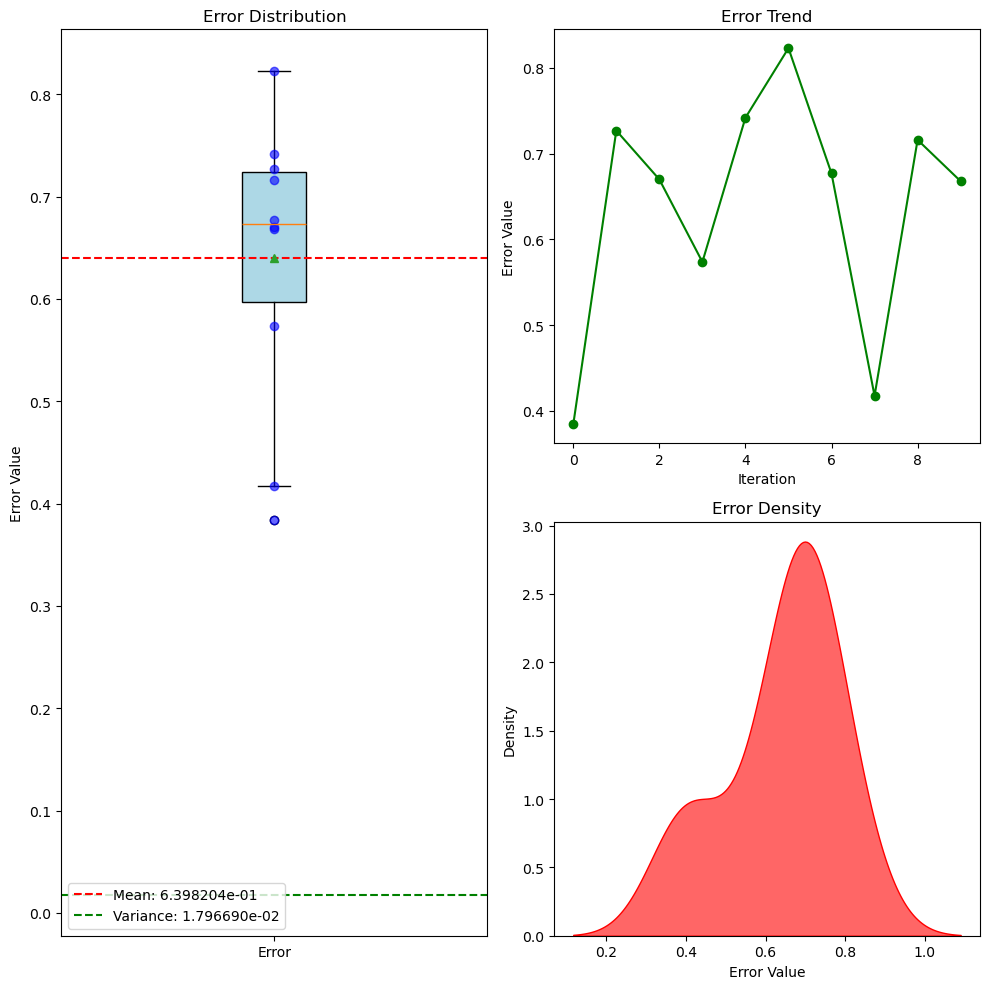

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  
error = error_u

plt.figure(figsize=(10, 10))  
plt.subplot(1, 2, 1) 
mean_error = np.mean(error)
var_error = np.var(error)
print('mean Error u: %e' % (mean_error)) 
print('Variance Error u: %e' % (var_error)) 


plt.subplot(1, 2, 1)
plt.boxplot(error, patch_artist=True, showmeans=True, meanline=False, boxprops=dict(facecolor='lightblue'))
plt.axhline(mean_error, color='r', linestyle='--', label=f'Mean: {mean_error:e}')
plt.axhline(var_error, color='g', linestyle='--', label=f'Variance: {var_error:e}')  
for i, value in enumerate(error):
    plt.plot(1, value, 'bo', alpha=0.6)
plt.title('Error Distribution')
plt.ylabel('Error Value')
plt.xticks([1], ['Error'])
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(error, '-o', color='green')
plt.title('Error Trend')
plt.ylabel('Error Value')
plt.xlabel('Iteration')

plt.subplot(2, 2, 4)
sns.kdeplot(error, shade=True, color="r", alpha=0.6)
plt.title('Error Density')
plt.xlabel('Error Value')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [17]:
len_t = 101
len_x = 101


flat_X = X_star[:, 0]
flat_T = X_star[:, 1]


X = flat_X.reshape(len_t, len_x)
T = flat_T.reshape(len_t, len_x)

U_star = griddata(X_star, u_star.flatten(), (X, T), method='cubic')


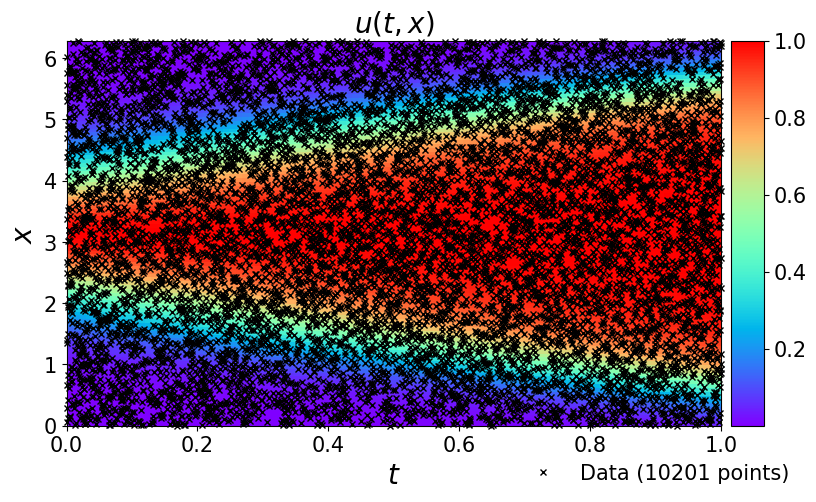

In [18]:
fig = plt.figure(figsize=(9, 5)) 
ax = fig.add_subplot(111) 
im = ax.imshow(U_star.T, interpolation='nearest', cmap='rainbow', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='auto')  


divider = make_axes_locatable(ax) 
cax = divider.append_axes("right", size="5%", pad=0.10) 
   
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=15) 
ax.plot(
    X_f[:,1], 
    X_f[:,0], 
    'kx', label = 'Data (%d points)' % (X_f.shape[0]), 
    markersize = 4,  
    clip_on = False,
    alpha=1.0
) 

ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.9, -0.05), 
    ncol=5, 
    frameon=False, 
    prop={'size': 15}
)
ax.set_title('$u(t,x)$', fontsize = 20) 
ax.tick_params(labelsize=15)

plt.show() 

In [19]:
trainloss = torch.stack(model.loss_value).cpu().detach().numpy()


12516


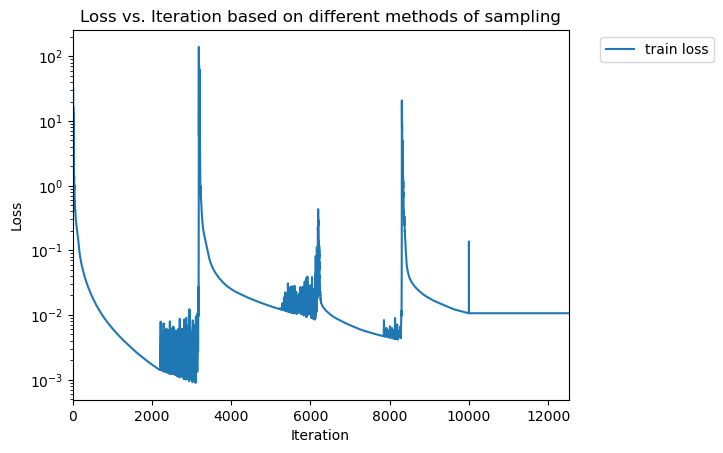

In [20]:
print(len(trainloss))

labels = ["Grid"]

plt.figure()


plt.plot(trainloss, label='train loss')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.xlim([0,len(trainloss)]) 
plt.yscale('log') 
plt.xlabel('Iteration') 
plt.ylabel('Loss') 
plt.title('Loss vs. Iteration based on different methods of sampling') 
plt.show()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


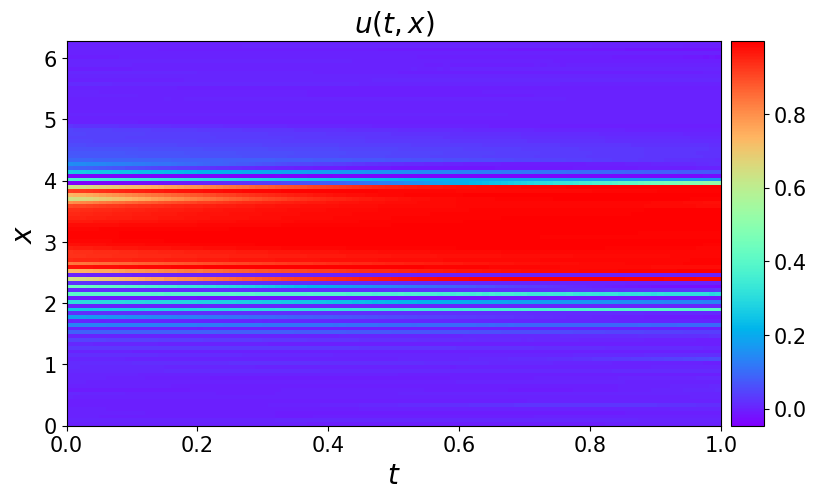

In [21]:
#使用griddata函数将X_star、u_pred插值到网格上，得到U_pred
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')


###### Row 0: u(t,x) ##################    

fig = plt.figure(figsize=(9, 5)) #这里figure是一个figure对象，是一个图形窗口，代表整个图形，设置图形大小为宽9英寸高5 英寸
ax = fig.add_subplot(111) #在图形的1*1网格的第一个位置添加一个子图

#绘图的数据来源
im = ax.imshow(U_pred.T, interpolation='nearest', cmap='rainbow', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='auto')   #imshow函数用于显示图像，接受一些参数，第一个参数是图像数据，这里是U_pred的转置；第二个参数是插值方法（用于在像素之间插入新的像素），这里是最邻近插值；


#添加颜色条
divider = make_axes_locatable(ax)  #使用 make_axes_locatable 函数创建了一个 AxesDivider 对象。这个函数接受一个 Axes 对象作为参数，返回一个 AxesDivider 对象。AxesDivider 对象可以用来管理子图的布局，特别是当你需要在一个图的旁边添加另一个图时。
cax = divider.append_axes("right", size="5%", pad=0.10) #使用append_axes方法在原始轴的右侧添加了一个新的轴。append_axes 方法接受三个参数：位置（"right"）、大小（"5%"）和间距（0.10）。在原始轴的右侧添加了一个新的轴，新轴的大小是原始轴的 5%，新轴与原始轴之间的间距是 0.05 英寸
   
cbar = fig.colorbar(im, cax=cax)#使用colorbar方法在新轴上添加了一个颜色条。colorbar 方法接受两个参数：axesimage 对象（im）和新轴（cax）。并记这个颜色条的名字是cbar
cbar.ax.tick_params(labelsize=15) #设置颜色条刻度标签大小，这里bar是之前定义的


# #在图上绘制散点图
# ax.plot(
#     X_f_train[:,1], 
#     X_f_train[:,0], 
#     'kx', label = 'Data (%d points)' % (X_f_train.shape[0]), 
#     markersize = 4,  # marker size doubled
#     clip_on = False,
#     alpha=1.0
# ) #在ax上绘制散点图，前两个参数是散点的x坐标和y坐标；kx表示黑色的x（散点形状是x），label是散点的标签，clip_on表示散点可以绘制在轴的边界外
#   #新加了一个alpha=1.0用来设置标记的透明度，1.0表示完全不透明  




#设置图的标签、图例、标题和刻度标签
#设置ax子图的x轴的标签为t，y轴的标签为x。这里$t$和$x$是latex格式的文本，用于生成数学公式
ax.set_xlabel('$t$', size=20)
ax.set_ylabel('$x$', size=20)
#设置子图ax的图例，第一个参数用来设置图例的位置，这里表示图例放在上方中央;第二个参数用来设置图例的锚点，接受一个元组，表示x和y坐标，表示把图例的锚点设置在x坐标为0.9，y坐标为-0.05处;frameon=False表示不显示图例的边框;第三个参数设置图例的列数，分为5列；最后一个参数设置图例属性，接受字典，这里表示设置图例字体大小为15；最后返回的leg是一个legend对象，表示图形的图例
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.9, -0.05), 
    ncol=5, 
    frameon=False, 
    prop={'size': 15}
)
#设置子图ax的标题为$u(t,x)$，表示latex格式的文本，用于生成数学公式，fontsize=10表示字体大小为20
ax.set_title('$u(t,x)$', fontsize = 20) # font size doubled，两倍化子图标题
ax.tick_params(labelsize=15)#用来设置刻度标签的大小。`tick_params`是`Axes`对象的一个方法，可以用来设置刻度线的属性。在这里，`labelsize=15` 是用来设置刻度标签的字体大小的。


#显示图片
plt.show() #显示所有打开的图形的函数

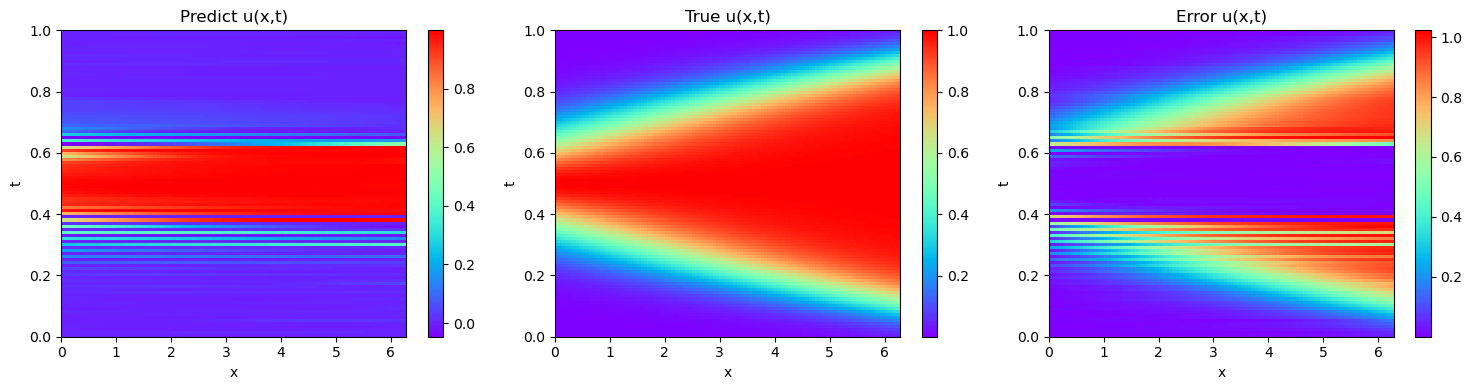

In [22]:

# 创建一个包含三幅子图的图像
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 绘制第一幅图像
axes[0].imshow(U_pred.T, extent=[0, np.pi*2, 1, 0], aspect='auto', cmap='rainbow')
axes[0].invert_yaxis()
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].set_title('Predict u(x,t)')
fig.colorbar(axes[0].images[0], ax=axes[0])

# 绘制第二幅图像
axes[1].imshow(U_star.T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[1].invert_yaxis()
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
axes[1].set_title('True u(x,t)')
fig.colorbar(axes[1].images[0], ax=axes[1])

# 绘制第三幅图像
axes[2].imshow(np.abs(U_pred - U_star).T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[2].invert_yaxis()
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
axes[2].set_title('Error u(x,t)')
fig.colorbar(axes[2].images[0], ax=axes[2])

# 自动调整子图参数，使得子图之间的间距适当
plt.tight_layout()
plt.show()

In [23]:
#计算训练好模型的chaos（最后一个seed）
u_chaos = calculate_chaos(model, X_star, num_iter=50)
u_chaos_log = np.log(u_chaos + 1e-10) #对u_var取对数，然后加上一个很小的数，避免取对数时出现错误

#使用griddata函数将X_star、u_pred插值到网格上，得到U_pred
U_chaos = griddata(X_star, u_chaos.flatten(), (X, T), method='cubic')
U_chaos_log = griddata(X_star, u_chaos_log.flatten(), (X, T), method='cubic')

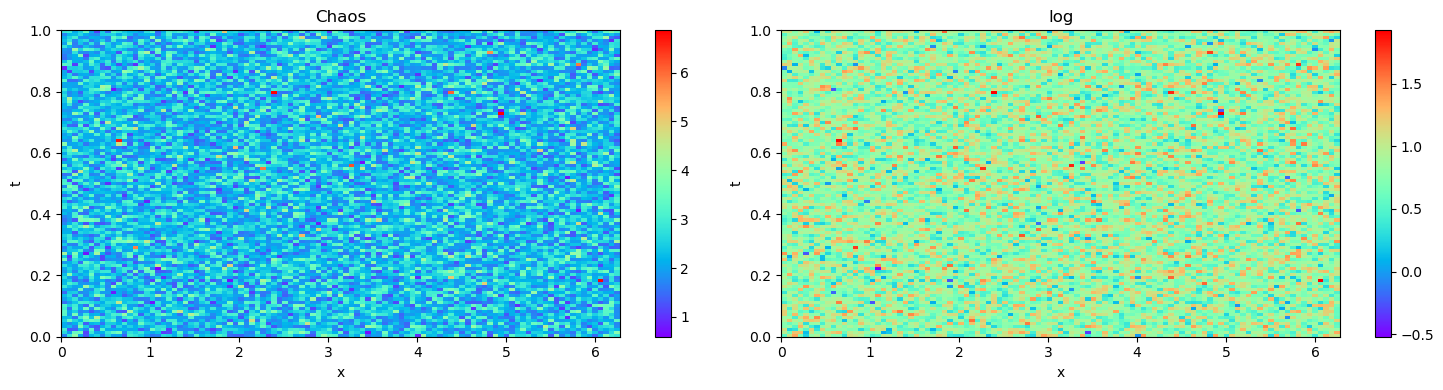

In [24]:

# 创建一个包含三幅子图的图像
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 绘制第一幅图像
axes[0].imshow(U_chaos.T, extent=[0, np.pi*2, 1, 0], aspect='auto', cmap='rainbow')
axes[0].invert_yaxis()
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].set_title('Chaos')
fig.colorbar(axes[0].images[0], ax=axes[0])

# 绘制第二幅图像
axes[1].imshow(U_chaos_log.T, extent=[0,np.pi*2,1,0], aspect='auto', cmap='rainbow') #第一个参数为数据，第二个参数为一个列表，用于设置图像的坐标范围，aspect='auto'表示纵横比自动调整
axes[1].invert_yaxis()
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
axes[1].set_title('log')
fig.colorbar(axes[1].images[0], ax=axes[1])

# 自动调整子图参数，使得子图之间的间距适当
plt.tight_layout()
plt.show()